# ⭐ Day 27: Jupyter Magic Commands & Best Practices

**Master Productivity Tools for AI & ML Development**

*Day 27 of 369-day Python & AI Learning Path*


## Introduction

Welcome to Day 27 of your comprehensive Python & AI Learning Journey! Today, we're unlocking the hidden superpowers of Jupyter notebooks that separate novice data scientists from professional ML engineers. **Jupyter magic commands** are special built-in commands—prefixed with `%` for line magics and `%%` for cell magics—that transform your notebook from a simple coding environment into a sophisticated, interactive development powerhouse.

Why invest time mastering these tools? In the high-stakes world of AI development, **experimentation velocity** is your competitive edge. Whether you're training billion-parameter models, processing terabyte-scale datasets, or debugging complex neural architectures, these magics provide instant access to performance profiling, interactive debugging, seamless file management, and environment control—all without ever leaving your notebook. Instead of context-switching between terminals, IDEs, and browsers, you accomplish complex workflows with elegant, single-line commands.

Beyond raw speed, these practices cultivate **professional-grade reproducibility**. The difference between a hobbyist and a senior ML engineer often lies in notebook hygiene: properly documented experiments, deterministic random seeds, version-control-friendly outputs, and logical cell organization. The techniques you'll master today are daily drivers at Google Research, OpenAI, DeepMind, and top-tier AI labs worldwide. They're not just conveniences—they're essential infrastructure for serious AI work.

By the end of this tutorial, you'll wield precision timing tools for optimization, debug interactively with surgical precision, manage external codebases seamlessly, and structure notebooks that future collaborators (including yourself) will genuinely enjoy working with. These skills compound exponentially—every minute saved on debugging or profiling is a minute invested in model innovation. Let's elevate your Jupyter mastery to the next level!


## 📋 Table of Contents

1. [Understanding Magic Commands](#understanding-magic-commands)
2. [Timing & Performance Profiling](#timing--performance-profiling)
3. [Variable & Environment Inspection](#variable--environment-inspection)
4. [File & Code Management](#file--code-management)
5. [Visualization & Display Control](#visualization--display-control)
6. [Development Workflow Tools](#development-workflow-tools)
7. [Debugging & Error Handling](#debugging--error-handling)
8. [Advanced Magics](#advanced-magics)
9. [Professional Best Practices](#professional-best-practices)
10. [🛠️ Hands-On Exercises](#hands-on-exercises)
11. [Solutions](#solutions)


---

## Understanding Magic Commands

Jupyter magic commands are special meta-commands that extend notebook functionality beyond standard Python. They fall into two categories:

- **Line Magics (`%`)**: Operate on the remainder of the current line. Can be used anywhere within a cell and accept arguments.
- **Cell Magics (`%%`)**: Must appear at the start of a cell. Transform the entire cell's content and behavior.

Let's explore the complete magic command landscape:


In [6]:
# Standard imports for AI/ML work
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import os
from pathlib import Path

# Display all available magic commands
%lsmagic


Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javascript

---

## Timing & Performance Profiling

### ⚡ Measuring Execution Time: `%time` vs `%timeit`

Accurate performance measurement is foundational in ML optimization. Use `%time` for single-run measurements and `%timeit` for statistical averaging over multiple iterations.


In [7]:
# Generate realistic ML dataset
np.random.seed(42)
data_size = 1_000_000
python_list = list(range(data_size))
numpy_array = np.arange(data_size)

# Inefficient Python loop approach (common beginner mistake)
def python_sum_squared(data):
    """Calculate sum of squares using pure Python."""
    total = 0
    for x in data:
        total += x ** 2
    return total

# Vectorized NumPy approach (professional standard)
def numpy_sum_squared(data):
    """Calculate sum of squares using NumPy vectorization."""
    return np.sum(data ** 2)

print("=" * 60)
print("SINGLE-RUN TIMING WITH %time")
print("=" * 60)


SINGLE-RUN TIMING WITH %time


In [8]:
# Single execution timing - useful for I/O bound operations
print("\n🐌 Python loop implementation:")
%time result_python = python_sum_squared(python_list)

print("\n⚡ NumPy vectorized implementation:")
%time result_numpy = numpy_sum_squared(numpy_array)

print(f"\nResults match: {result_python == result_numpy}")



🐌 Python loop implementation:
CPU times: total: 1.05 s
Wall time: 2.09 s

⚡ NumPy vectorized implementation:
CPU times: total: 78.1 ms
Wall time: 72.4 ms

Results match: True


In [9]:
# Statistical timing with %timeit - crucial for CPU-bound operations
print("=" * 60)
print("STATISTICAL TIMING WITH %timeit")
print("=" * 60)

print("\n🐌 Python loop (averaged over multiple runs):")
%timeit python_sum_squared(python_list[:100000])  # Smaller subset for timeit

print("\n⚡ NumPy vectorized (averaged over multiple runs):")
%timeit numpy_sum_squared(numpy_array[:100000])


STATISTICAL TIMING WITH %timeit

🐌 Python loop (averaged over multiple runs):


357 ms ± 75.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

⚡ NumPy vectorized (averaged over multiple runs):
3.26 ms ± 886 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


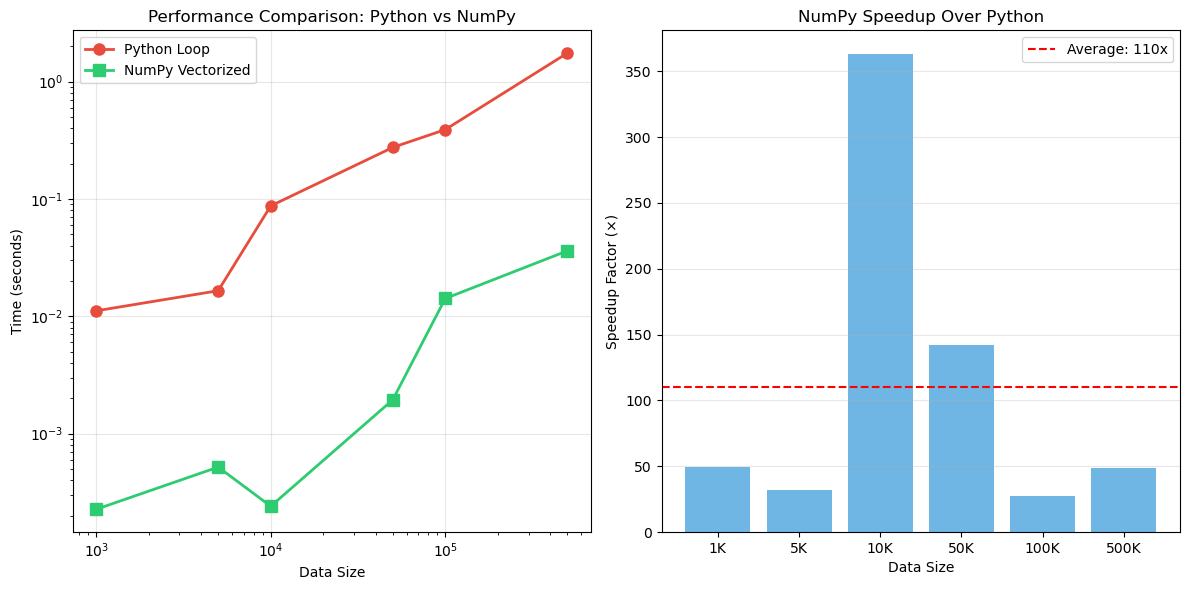

Average speedup: 110.3x faster with NumPy!


In [10]:
# Visualizing performance comparison across different data sizes
sizes = [1000, 5000, 10000, 50000, 100000, 500000]
python_times = []
numpy_times = []

for size in sizes:
    # Time Python loop
    start = time.perf_counter()
    python_sum_squared(list(range(size)))
    python_times.append(time.perf_counter() - start)
    
    # Time NumPy
    start = time.perf_counter()
    numpy_sum_squared(np.arange(size))
    numpy_times.append(time.perf_counter() - start)

# Plotting performance comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(sizes, python_times, 'o-', label='Python Loop', color='#e74c3c', linewidth=2, markersize=8)
plt.plot(sizes, numpy_times, 's-', label='NumPy Vectorized', color='#2ecc71', linewidth=2, markersize=8)
plt.xlabel('Data Size')
plt.ylabel('Time (seconds)')
plt.title('Performance Comparison: Python vs NumPy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Speedup ratio
speedup = np.array(python_times) / np.array(numpy_times)
plt.subplot(1, 2, 2)
plt.bar(range(len(sizes)), speedup, color='#3498db', alpha=0.7)
plt.axhline(y=np.mean(speedup), color='red', linestyle='--', label=f'Average: {np.mean(speedup):.0f}x')
plt.xticks(range(len(sizes)), [f'{s//1000}K' for s in sizes])
plt.xlabel('Data Size')
plt.ylabel('Speedup Factor (×)')
plt.title('NumPy Speedup Over Python')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Average speedup: {np.mean(speedup):.1f}x faster with NumPy!")


### ⚡ Cell-Level Timing with `%%time` and `%%timeit`

Cell magics time entire blocks of code—perfect for profiling data preprocessing pipelines or model training loops.


In [11]:
%%time
# Timing an entire data preprocessing pipeline
print("Executing full preprocessing pipeline...")

# Simulate loading large dataset
raw_data = np.random.randn(10000, 50)

# Data cleaning
clean_data = raw_data[~np.isnan(raw_data).any(axis=1)]

# Feature normalization
mean_vals = np.mean(clean_data, axis=0)
std_vals = np.std(clean_data, axis=0)
normalized = (clean_data - mean_vals) / (std_vals + 1e-8)

# Train/test split
split_idx = int(0.8 * len(normalized))
train_data = normalized[:split_idx]
test_data = normalized[split_idx:]

print(f"Pipeline complete. Train shape: {train_data.shape}, Test shape: {test_data.shape}")


Executing full preprocessing pipeline...
Pipeline complete. Train shape: (8000, 50), Test shape: (2000, 50)
CPU times: total: 125 ms
Wall time: 252 ms


In [12]:
%%timeit -n 3 -r 2
# Timeit with custom iterations and runs
# Simulating a model forward pass
batch_size = 256
input_dim = 784
hidden_dim = 128
output_dim = 10

# Random weights (simulating neural network)
W1 = np.random.randn(input_dim, hidden_dim)
b1 = np.random.randn(hidden_dim)
W2 = np.random.randn(hidden_dim, output_dim)
b2 = np.random.randn(output_dim)

# Forward pass
batch = np.random.randn(batch_size, input_dim)
hidden = np.maximum(0, batch @ W1 + b1)  # ReLU
output = hidden @ W2 + b2

_ = np.argmax(output, axis=1)  # Predictions


129 ms ± 26.2 ms per loop (mean ± std. dev. of 2 runs, 3 loops each)


---

## Variable & Environment Inspection

### 📊 Workspace Management: `%who`, `%whos`, `%who_ls`

Maintain clean workspace awareness—essential when juggling multiple datasets and models.


In [13]:
# Create diverse variable types typical in ML workflows
model_params = {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
training_data = np.random.randn(5000, 10)
target_labels = np.random.randint(0, 2, 5000)
feature_names = [f'feature_{i}' for i in range(10)]
accuracy_score = 0.947
is_trained = True
model_history = {'loss': [0.5, 0.3, 0.2], 'val_loss': [0.6, 0.4, 0.35]}

print("Variables created successfully!")


Variables created successfully!


In [14]:
# Quick variable name listing
print("Quick variable inventory:")
%who


Quick variable inventory:
Path	 accuracy_score	 clean_data	 data_size	 debuggable_function	 feature_names	 is_trained	 mean_vals	 model_history	 
model_params	 normalized	 np	 numpy_array	 numpy_sum_squared	 numpy_times	 os	 pd	 plt	 
python_list	 python_sum_squared	 python_times	 random	 raw_data	 result_numpy	 result_python	 setup_reproducibility	 size	 
sizes	 speedup	 split_idx	 start	 std_vals	 target_labels	 test_data	 time	 train_data	 
training_data	 


In [15]:
# Detailed inspection with types and memory usage
print("Detailed workspace analysis:")
%whos


Detailed workspace analysis:
Variable                Type        Data/Info
---------------------------------------------
Path                    type        <class 'pathlib._local.Path'>
accuracy_score          float       0.947
clean_data              ndarray     10000x50: 500000 elems, type `float64`, 4000000 bytes (3.814697265625 Mb)
data_size               int         1000000
debuggable_function     function    <function debuggable_func<...>on at 0x0000016EB35F2FC0>
feature_names           list        n=10
is_trained              bool        True
mean_vals               ndarray     50: 50 elems, type `float64`, 400 bytes
model_history           dict        n=2
model_params            dict        n=3
normalized              ndarray     10000x50: 500000 elems, type `float64`, 4000000 bytes (3.814697265625 Mb)
np                      module      <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
numpy_array             ndarray     1000000: 1000000 elems, type `int64`, 8000000 byt

In [16]:
# Programmatic access to variable names
variable_names = %who_ls
print(f"Total variables in workspace: {len(variable_names)}")
print(f"Variable names: {sorted(variable_names)}")

# Filter by type
arrays = [name for name in variable_names if isinstance(globals()[name], np.ndarray)]
print(f"\nNumPy arrays: {arrays}")


Total variables in workspace: 37
Variable names: ['Path', 'accuracy_score', 'clean_data', 'data_size', 'debuggable_function', 'feature_names', 'is_trained', 'mean_vals', 'model_history', 'model_params', 'normalized', 'np', 'numpy_array', 'numpy_sum_squared', 'numpy_times', 'os', 'pd', 'plt', 'python_list', 'python_sum_squared', 'python_times', 'random', 'raw_data', 'result_numpy', 'result_python', 'setup_reproducibility', 'size', 'sizes', 'speedup', 'split_idx', 'start', 'std_vals', 'target_labels', 'test_data', 'time', 'train_data', 'training_data']

NumPy arrays: ['clean_data', 'mean_vals', 'normalized', 'numpy_array', 'raw_data', 'speedup', 'std_vals', 'target_labels', 'test_data', 'train_data', 'training_data']


### 📊 Object Introspection: `%pinfo` and `?`

Quick access to documentation without leaving your workflow.


In [17]:
# Detailed information about objects
print("Inspecting numpy.sum function:")
%pinfo np.sum


Inspecting numpy.sum function:


Signature:      
np.sum(
    a,
    axis=None,
    dtype=None,
    out=None,
    keepdims=<no value>,
    initial=<no value>,
    where=<no value>,
)
Call signature:  np.sum(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function sum at 0x0000016EB9F6F560>
File:            c:\users\786\miniconda3\envs\env_dl\lib\site-packages\numpy\_core\fromnumeric.py
Docstring:      
Sum of array elements over a given axis.

Parameters
----------
a : array_like
    Elements to sum.
axis : None or int or tuple of ints, optional
    Axis or axes along which a sum is performed.  The default,
    axis=None, will sum all of the elements of the input array.  If
    axis is negative it counts from the last to the first axis. If
    axis is a tuple of ints, a sum is performed on all of the axes
    specified in the tuple instead of a single axis or all the axes as
    before.
dtype : dtype, optional
    The type of the returned array and of the accumulator in which the
    eleme

In [18]:
# Shorthand with ? operator
print("Quick docstring for pandas.DataFrame:")
pd.DataFrame?


Quick docstring for pandas.DataFrame:


Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

---

## File & Code Management

### 💡 External Code Integration: `%load`, `%run`, `%save`

Seamlessly work with external Python modules—critical for production ML workflows.


In [19]:
# First, create a reusable ML utilities module using %%writefile
# (Demonstrated in next section - this creates the file we'll load)

utility_code = '''
"""
ML Utility Functions
Production-ready helper functions for data preprocessing.
"""
import numpy as np
from typing import Tuple, Optional

def robust_scale(X: np.ndarray, quantile_range: Tuple[float, float] = (25.0, 75.0)) -> np.ndarray:
    """
    Robust scaling using median and IQR (interquartile range).
    
    More robust to outliers than standard z-score normalization.
    """
    median = np.median(X, axis=0)
    q1 = np.percentile(X, quantile_range[0], axis=0)
    q3 = np.percentile(X, quantile_range[1], axis=0)
    iqr = q3 - q1
    return (X - median) / (iqr + 1e-8)

def train_val_test_split(
    X: np.ndarray, 
    y: np.ndarray, 
    val_size: float = 0.1, 
    test_size: float = 0.1,
    random_state: Optional[int] = None
) -> Tuple:
    """
    Split data into train/validation/test sets.
    
    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    """
    if random_state:
        np.random.seed(random_state)
    
    n = len(X)
    indices = np.random.permutation(n)
    
    test_end = int(n * test_size)
    val_end = test_end + int(n * val_size)
    
    test_idx = indices[:test_end]
    val_idx = indices[test_end:val_end]
    train_idx = indices[val_end:]
    
    return (
        X[train_idx], X[val_idx], X[test_idx],
        y[train_idx], y[val_idx], y[test_idx]
    )

print("✅ ML utilities module loaded successfully!")
'''

# Save to file
with open('ml_utils.py', 'w', encoding='utf-8') as f:
    f.write(utility_code)

print("Created ml_utils.py")

Created ml_utils.py


In [20]:
# Execute external Python script
%run ml_utils.py

# Test the loaded functions
X_demo = np.random.randn(1000, 5)
y_demo = np.random.randint(0, 2, 1000)

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X_demo, y_demo, val_size=0.15, test_size=0.15, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

X_scaled = robust_scale(X_train)
print(f"Scaled features - Mean: {np.mean(X_scaled):.3f}, Std: {np.std(X_scaled):.3f}")


✅ ML utilities module loaded successfully!
Train: (700, 5), Val: (150, 5), Test: (150, 5)
Scaled features - Mean: -0.009, Std: 0.726


### 💡 Creating Modules with `%%writefile`

Transform notebook cells into reusable Python modules.


In [21]:
%%writefile preprocessing.py
"""
Data Preprocessing Pipeline
Version: 1.0.0
Author: AI Learning Path
"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Transformer that clips outliers to specified percentiles.
    
    Parameters:
    -----------
    lower_percentile : float
        Lower bound percentile (0-100)
    upper_percentile : float
        Upper bound percentile (0-100)
    """
    
    def __init__(self, lower_percentile=1.0, upper_percentile=99.0):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.lower_bounds_ = None
        self.upper_bounds_ = None
    
    def fit(self, X, y=None):
        self.lower_bounds_ = np.percentile(X, self.lower_percentile, axis=0)
        self.upper_bounds_ = np.percentile(X, self.upper_percentile, axis=0)
        return self
    
    def transform(self, X):
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

def create_polynomial_features(X, degree=2):
    """Generate polynomial features up to specified degree."""
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    return poly.fit_transform(X)

if __name__ == "__main__":
    # Demo
    data = np.random.randn(100, 3)
    clipper = OutlierClipper()
    clipped = clipper.fit_transform(data)
    print(f"Original range: [{data.min():.2f}, {data.max():.2f}]")
    print(f"Clipped range: [{clipped.min():.2f}, {clipped.max():.2f}]")


Writing preprocessing.py


In [22]:
# Verify file creation and test the module
%run preprocessing.py

# Demonstrate usage
raw_data = np.random.randn(500, 4) * 10  # Data with outliers
raw_data[0] = 100  # Inject outlier
raw_data[1] = -100  # Inject outlier

clipper = OutlierClipper(lower_percentile=2, upper_percentile=98)
clean_data = clipper.fit_transform(raw_data)

print(f"Original std: {np.std(raw_data):.2f}")
print(f"Cleaned std: {np.std(clean_data):.2f}")
print(f"Outliers removed: {np.sum(raw_data != clean_data)} values clipped")


Original range: [-2.66, 2.64]
Clipped range: [-2.33, 2.54]
Original std: 11.64
Cleaned std: 9.55
Outliers removed: 80 values clipped


---

## Visualization & Display Control

### 📊 Matplotlib Backend Configuration

Control how plots render for optimal workflow and publication quality.


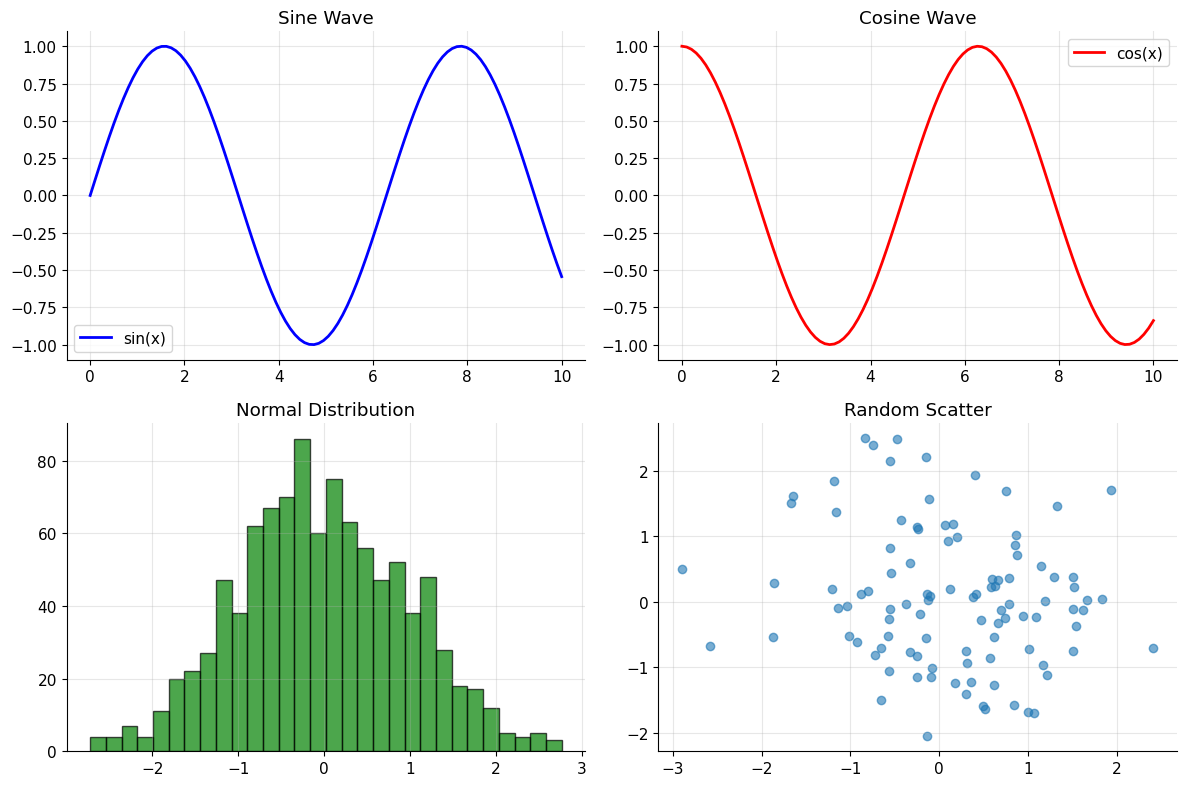

In [23]:
# Standard inline backend - static images, good for publications
%matplotlib inline

# Configure figure aesthetics
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Generate sample visualization
x = np.linspace(0, 10, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
axes[0, 0].set_title('Sine Wave')
axes[0, 0].legend()

axes[0, 1].plot(x, np.cos(x), 'r-', linewidth=2, label='cos(x)')
axes[0, 1].set_title('Cosine Wave')
axes[0, 1].legend()

data = np.random.randn(1000)
axes[1, 0].hist(data, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Normal Distribution')

axes[1, 1].scatter(np.random.randn(100), np.random.randn(100), alpha=0.6)
axes[1, 1].set_title('Random Scatter')

plt.tight_layout()
plt.show()


In [24]:
# Configure inline backend for higher resolution
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}

print("Inline backend configured for high-resolution output!")


Inline backend configured for high-resolution output!


---

## Development Workflow Tools

### 🔧 Auto-Reload for Development

**The most critical magic for iterative ML development!** Automatically reloads external modules when edited.


In [25]:
# Load and configure autoreload extension
%load_ext autoreload

# Mode 2: Reload all modules (except excluded) before executing code
%autoreload 2

# Optional: Exclude specific modules from reloading
# %aimport -preprocessing  # Exclude preprocessing module

print("✅ Autoreload enabled! Edit ml_utils.py or preprocessing.py and changes will reflect immediately.")
print("Try modifying a function in ml_utils.py and re-running it without kernel restart!")


✅ Autoreload enabled! Edit ml_utils.py or preprocessing.py and changes will reflect immediately.
Try modifying a function in ml_utils.py and re-running it without kernel restart!


### 🔧 Environment & Directory Management

Navigate and configure your environment programmatically.


In [26]:
# Directory navigation
print("Current working directory:")
%pwd


Current working directory:


'd:\\artificial intelligence\\027_ai'

In [27]:
# List directory contents
print("Python files in current directory:")
%ls -lh *.py


Python files in current directory:
 Volume in drive D has no label.
 Volume Serial Number is E2BB-5EA2

 Directory of d:\artificial intelligence\027_ai


 Directory of d:\artificial intelligence\027_ai

04/06/2026  07:08 AM             1,411 ml_utils.py
04/06/2026  07:08 AM             1,609 preprocessing.py
               2 File(s)          3,020 bytes
               0 Dir(s)  116,327,600,128 bytes free


In [28]:
# Environment variables
print("Setting ML experiment environment variables...")

%env ML_PROJECT_NAME=Day27_MagicCommands
%env ML_EXPERIMENT_ID=EXP-2024-027
%env PYTHONHASHSEED=42

# Verify in Python
import os
print(f"\nProject: {os.environ.get('ML_PROJECT_NAME')}")
print(f"Experiment: {os.environ.get('ML_EXPERIMENT_ID')}")


Setting ML experiment environment variables...
env: ML_PROJECT_NAME=Day27_MagicCommands
env: ML_EXPERIMENT_ID=EXP-2024-027
env: PYTHONHASHSEED=42

Project: Day27_MagicCommands
Experiment: EXP-2024-027


---

## Debugging & Error Handling

### 🐛 Interactive Debugging with `%pdb`

Step through code execution when exceptions occur.


In [29]:
# Enable automatic debugger on exceptions
%pdb on

# Configure exception reporting mode
%xmode Context

def buggy_data_processor(data, scale_factor):
    """Function with intentional bugs for demonstration."""
    processed = []
    for i, val in enumerate(data):
        # Bug 1: Division by zero possible
        normalized = val / scale_factor
        
        # Bug 2: Index error on last element
        next_val = data[i + 1] # Will fail at last index
        
        processed.append(normalized + next_val)
    return processed

# Uncomment to trigger debugger:
# test_data = [1, 2, 3, 4, 5]
# buggy_data_processor(test_data, 0)  # Division by zero

print("Debugger configured. Uncomment test code to see interactive debugging.")
print("Commands in pdb: 'n' (next), 's' (step), 'c' (continue), 'q' (quit)")
print("Inspect variables by name: type 'scale_factor' or 'data[i]' in pdb prompt")

Automatic pdb calling has been turned ON
Exception reporting mode: Context
Debugger configured. Uncomment test code to see interactive debugging.
Commands in pdb: 'n' (next), 's' (step), 'c' (continue), 'q' (quit)
Inspect variables by name: type 'scale_factor' or 'data[i]' in pdb prompt


In [30]:
# Manual breakpoint insertion
def debuggable_function(x, y):
    result = x + y
    # You can manually set breakpoints with 'breakpoint()' in Python 3.7+
    # Or use %debug after an error occurs
    return result * 2

# Post-mortem debugging: %debug enters debugger at last exception
print("Use %debug after an exception to inspect post-mortem")


Use %debug after an exception to inspect post-mortem


---

## Advanced Magics

### ✨ Multi-Language Support

Execute code in other languages directly in your notebook.


In [1]:
%%html
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            padding: 25px; border-radius: 12px; color: white;
            font-family: 'Segoe UI', sans-serif; box-shadow: 0 8px 32px rgba(0,0,0,0.2);">
    <h2 style="margin-top: 0;">🎨 Rich HTML in Notebooks</h2>
    <p style="font-size: 16px; line-height: 1.6;">
        You can create <strong>beautiful, interactive documentation</strong> using HTML magics!
    </p>
    <ul style="font-size: 14px;">
        <li>📊 Custom progress indicators</li>
        <li>🎨 Styled alert boxes</li>
        <li>📱 Responsive layouts</li>
        <li>🎯 Interactive elements</li>
    </ul>
    <div style="margin-top: 15px; padding: 10px; background: rgba(255,255,255,0.2); 
                border-radius: 6px; font-family: monospace; font-size: 12px;">
        Tip: Combine with IPython.display for dynamic updates!
    </div>
</div>


In [3]:
# Bookmark frequently used directories
%bookmark ml_projects /home/user/projects/ml
%bookmark data /home/user/datasets

print("Bookmarks created! Use %bookmark -l to list, %cd -b ml_projects to jump")
%bookmark -l


Bookmarks created! Use %bookmark -l to list, %cd -b ml_projects to jump
Current bookmarks:
data        -> /home/user/datasets
ml_projects -> /home/user/projects/ml


---

## Professional Best Practices

### ✅ Reproducible Experiments

Ensure your ML experiments are fully reproducible.


In [5]:
import numpy as np

def setup_reproducibility(seed: int = 42) -> None:
    """
    Configure environment for fully reproducible ML experiments.
    
    Args:
        seed: Master random seed for all libraries
    """
    import os
    import random
    import numpy as np
    
    # Python environment
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Python standard library
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch (if available)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        print("✅ PyTorch seeds configured")
    except ImportError:
        pass
    
    # TensorFlow (if available)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
        print("✅ TensorFlow seeds configured")
    except ImportError:
        pass
    
    print(f"🎯 Full reproducibility mode enabled (seed: {seed})")

# Execute
setup_reproducibility(42)

# Verify
print(f"\nVerification - NumPy random: {np.random.randn(3)}")
setup_reproducibility(42)
print(f"Verification - NumPy random: {np.random.randn(3)}")

✅ TensorFlow seeds configured
🎯 Full reproducibility mode enabled (seed: 42)

Verification - NumPy random: [ 0.49671415 -0.1382643   0.64768854]
✅ TensorFlow seeds configured
🎯 Full reproducibility mode enabled (seed: 42)
Verification - NumPy random: [ 0.49671415 -0.1382643   0.64768854]


### ✅ Clean Notebook Structure

Template for professional notebook organization:

```markdown
# 1. Configuration & Setup
- Imports
- Constants
- Seed setting

# 2. Data Loading
- Load raw data
- Initial validation

# 3. Exploratory Data Analysis
- Statistics
- Visualizations

# 4. Preprocessing
- Cleaning
- Feature engineering

# 5. Modeling
- Model definition
- Training

# 6. Evaluation
- Metrics
- Analysis

# 7. Results & Export
- Save models
- Generate reports
```


### ✅ Essential Keyboard Shortcuts

Master these for maximum productivity:

| Mode | Shortcut | Action |
|------|----------|--------|
| Edit | `Ctrl + Enter` | Run cell |
| Edit | `Shift + Enter` | Run cell, select next |
| Edit | `Alt + Enter` | Run cell, insert below |
| Edit | `Ctrl + Shift + -` | Split cell |
| Edit | `Ctrl + /` | Toggle comment |
| Command | `Esc` | Enter command mode |
| Command | `Enter` | Enter edit mode |
| Command | `A` | Insert cell above |
| Command | `B` | Insert cell below |
| Command | `DD` | Delete cell |
| Command | `M` | Convert to Markdown |
| Command | `Y` | Convert to code |
| Command | `Shift + M` | Merge selected cells |
| Command | `L` | Toggle line numbers |
| Command | `O` | Toggle output |


---

## 🛠️ Hands-On Exercises

Complete these exercises to solidify your mastery. Attempt each before checking solutions!

### Exercise 1: Performance Profiling
Compare three methods for calculating the mean of squared values: (1) Python list comprehension with loop, (2) NumPy vectorized operation, (3) Pandas Series method. Use `%timeit` to find the fastest approach for 100,000 elements.


In [6]:
# your code here


### Exercise 2: Workspace Inspection
Create five variables of different types (int, list, dict, numpy array, string). Use `%whos` to analyze memory usage, then use `%who_ls` to programmatically filter only numpy arrays.


In [7]:
# your code here


### Exercise 3: Module Creation
Use `%%writefile` to create a `metrics.py` file containing functions for accuracy, precision, and recall calculations. Then use `%run` to import and test with sample predictions and labels.


In [8]:
# your code here


### Exercise 4: Autoreload Workflow
Enable autoreload mode 2, create a `utils.py` with a `greet()` function, test it, then modify the file to add a `farewell()` function without restarting the kernel. Demonstrate both functions work.


In [9]:
# your code here


### Exercise 5: Environment Setup
Set three environment variables (`MODEL_NAME`, `BATCH_SIZE`, `LEARNING_RATE`) using `%env`, then create a Python dictionary from `os.environ` containing only these keys and print it.


In [10]:
# your code here


### Exercise 6: Visualization Backend
Configure matplotlib inline backend with `'retina'` format and tight bounding boxes. Create a 2x2 subplot showing sine, cosine, exponential, and logarithmic functions with proper styling.


In [11]:
# your code here


### Exercise 7: Debugging Practice
Write a function `safe_divide_list(numbers, divisor)` that divides each number but crashes on zero divisor. Enable `%pdb on`, call it with a zero divisor, and practice navigating the debugger (then comment out to continue).


In [12]:
# your code here


### Exercise 8: Shell Integration
Use `%%bash` to create a directory `experiment_artifacts`, list all `.py` files in current directory with human-readable sizes, and save the output to `experiment_artifacts/file_list.txt`.


In [13]:
# your code here


### Exercise 9: Precision Control
Generate a 5x5 random matrix, display with default precision, then use `%precision 3` to show 3 decimal places, and finally reset to default using `%precision %r`.


In [14]:
# your code here


### Exercise 10: Complete Workflow
Combine multiple magics in an ML workflow: (1) Set random seed, (2) Generate synthetic classification data (1000 samples, 10 features), (3) Time a preprocessing function with `%%time`, (4) Save the preprocessor to a file with `%%writefile`, (5) Use `%%bash` to check file exists, (6) List all variables with `%whos`.


In [15]:
# your code here


---

## Solutions

**Try the exercises first before checking these solutions!**

### Solution 1: Performance Profiling


In [16]:
import pandas as pd

data_size = 100000
python_list = list(range(data_size))
numpy_array = np.arange(data_size)
pandas_series = pd.Series(numpy_array)

def method_python(data):
    """Pure Python list comprehension."""
    squared = [x**2 for x in data]
    return sum(squared) / len(squared)

def method_numpy(data):
    """NumPy vectorized."""
    return np.mean(data**2)

def method_pandas(series):
    """Pandas method."""
    return (series**2).mean()

print("Performance comparison (100,000 elements):")
print("\n1. Python list comprehension:")
%timeit method_python(python_list)

print("\n2. NumPy vectorized:")
%timeit method_numpy(numpy_array)

print("\n3. Pandas Series:")
%timeit method_pandas(pandas_series)

# Winner is typically NumPy, followed closely by Pandas, with Python far behind


Performance comparison (100,000 elements):

1. Python list comprehension:
388 ms ± 90.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

2. NumPy vectorized:
3.59 ms ± 337 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

3. Pandas Series:
5.58 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Solution 2: Workspace Inspection


In [17]:
# Create diverse variables
counter = 42
data_list = [1, 2, 3, 4, 5]
config_dict = {'lr': 0.01, 'epochs': 10}
matrix = np.random.randn(100, 50)
description = "Machine Learning Experiment"

print("Detailed workspace analysis:")
%whos

print("\n" + "="*50)
print("Filtering only NumPy arrays:")
all_vars = %who_ls
arrays_only = [name for name in all_vars 
               if isinstance(globals().get(name), np.ndarray)]
print(f"NumPy arrays found: {arrays_only}")
for name in arrays_only:
    arr = globals()[name]
    print(f"  {name}: shape={arr.shape}, dtype={arr.dtype}")


Detailed workspace analysis:
Variable                Type        Data/Info
---------------------------------------------
config_dict             dict        n=2
counter                 int         42
data_list               list        n=5
data_size               int         100000
description             str         Machine Learning Experiment
matrix                  ndarray     100x50: 5000 elems, type `float64`, 40000 bytes
method_numpy            function    <function method_numpy at 0x000002A6F071C680>
method_pandas           function    <function method_pandas at 0x000002A6F071C7C0>
method_python           function    <function method_python at 0x000002A6F071C180>
np                      module      <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
numpy_array             ndarray     100000: 100000 elems, type `int64`, 800000 bytes (781.25 kb)
pandas_series           Series      Shape: (100000,)
pd                      module      <module 'pandas' from 'c:<...>es\\pandas\\_

### Solution 3: Module Creation


In [18]:
%%writefile metrics.py
"""
Classification metrics module.
"""
import numpy as np

def accuracy(y_true, y_pred):
    """Calculate accuracy."""
    return np.mean(np.array(y_true) == np.array(y_pred))

def precision(y_true, y_pred):
    """Calculate precision (positive predictive value)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(y_true, y_pred):
    """Calculate recall (sensitivity)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

if __name__ == "__main__":
    # Test
    y_t = [1, 0, 1, 1, 0, 1, 0, 0]
    y_p = [1, 0, 1, 0, 0, 1, 1, 0]
    print(f"Accuracy: {accuracy(y_t, y_p):.2f}")
    print(f"Precision: {precision(y_t, y_p):.2f}")
    print(f"Recall: {recall(y_t, y_p):.2f}")


Writing metrics.py


In [19]:
# Run and test
%run metrics.py

# Test with new data
y_true = np.random.randint(0, 2, 100)
y_pred = np.random.randint(0, 2, 100)

print(f"\nTest with random data (n=100):")
print(f"Accuracy: {accuracy(y_true, y_pred):.3f}")
print(f"Precision: {precision(y_true, y_pred):.3f}")
print(f"Recall: {recall(y_true, y_pred):.3f}")


Accuracy: 0.75
Precision: 0.75
Recall: 0.75

Test with random data (n=100):
Accuracy: 0.550
Precision: 0.475
Recall: 0.690


### Solution 4: Autoreload Workflow


In [20]:
# Enable autoreload
%load_ext autoreload
%autoreload 2

# Create initial utils.py
initial_code = '''
def greet(name):
    return f"Hello, {name}!"
'''

with open('utils.py', 'w') as f:
    f.write(initial_code)

print("Created utils.py with greet() function")


Created utils.py with greet() function


In [21]:
# Test initial function
from utils import greet
print(greet("World"))

# Now modify file (simulating external edit)
updated_code = '''
def greet(name):
    return f"Hello, {name}!"

def farewell(name):
    return f"Goodbye, {name}!"
'''

with open('utils.py', 'w') as f:
    f.write(updated_code)

print("\nAdded farewell() function to utils.py")
print("(Autoreload should pick this up automatically)")


Hello, World!

Added farewell() function to utils.py
(Autoreload should pick this up automatically)


### Solution 5: Environment Setup


In [23]:
# Set environment variables
%env MODEL_NAME=ResNet50
%env BATCH_SIZE=32
%env LEARNING_RATE=0.001

# Extract into dictionary
import os

ml_config = {
    'MODEL_NAME': os.environ.get('MODEL_NAME'),
    'BATCH_SIZE': int(os.environ.get('BATCH_SIZE')),
    'LEARNING_RATE': float(os.environ.get('LEARNING_RATE'))
}

print("ML Configuration:")
for key, value in ml_config.items():
    print(f"  {key}: {value} ({type(value).__name__})")


env: MODEL_NAME=ResNet50
env: BATCH_SIZE=32
env: LEARNING_RATE=0.001
ML Configuration:
  MODEL_NAME: ResNet50 (str)
  BATCH_SIZE: 32 (int)
  LEARNING_RATE: 0.001 (float)


### Solution 6: Visualization Backend


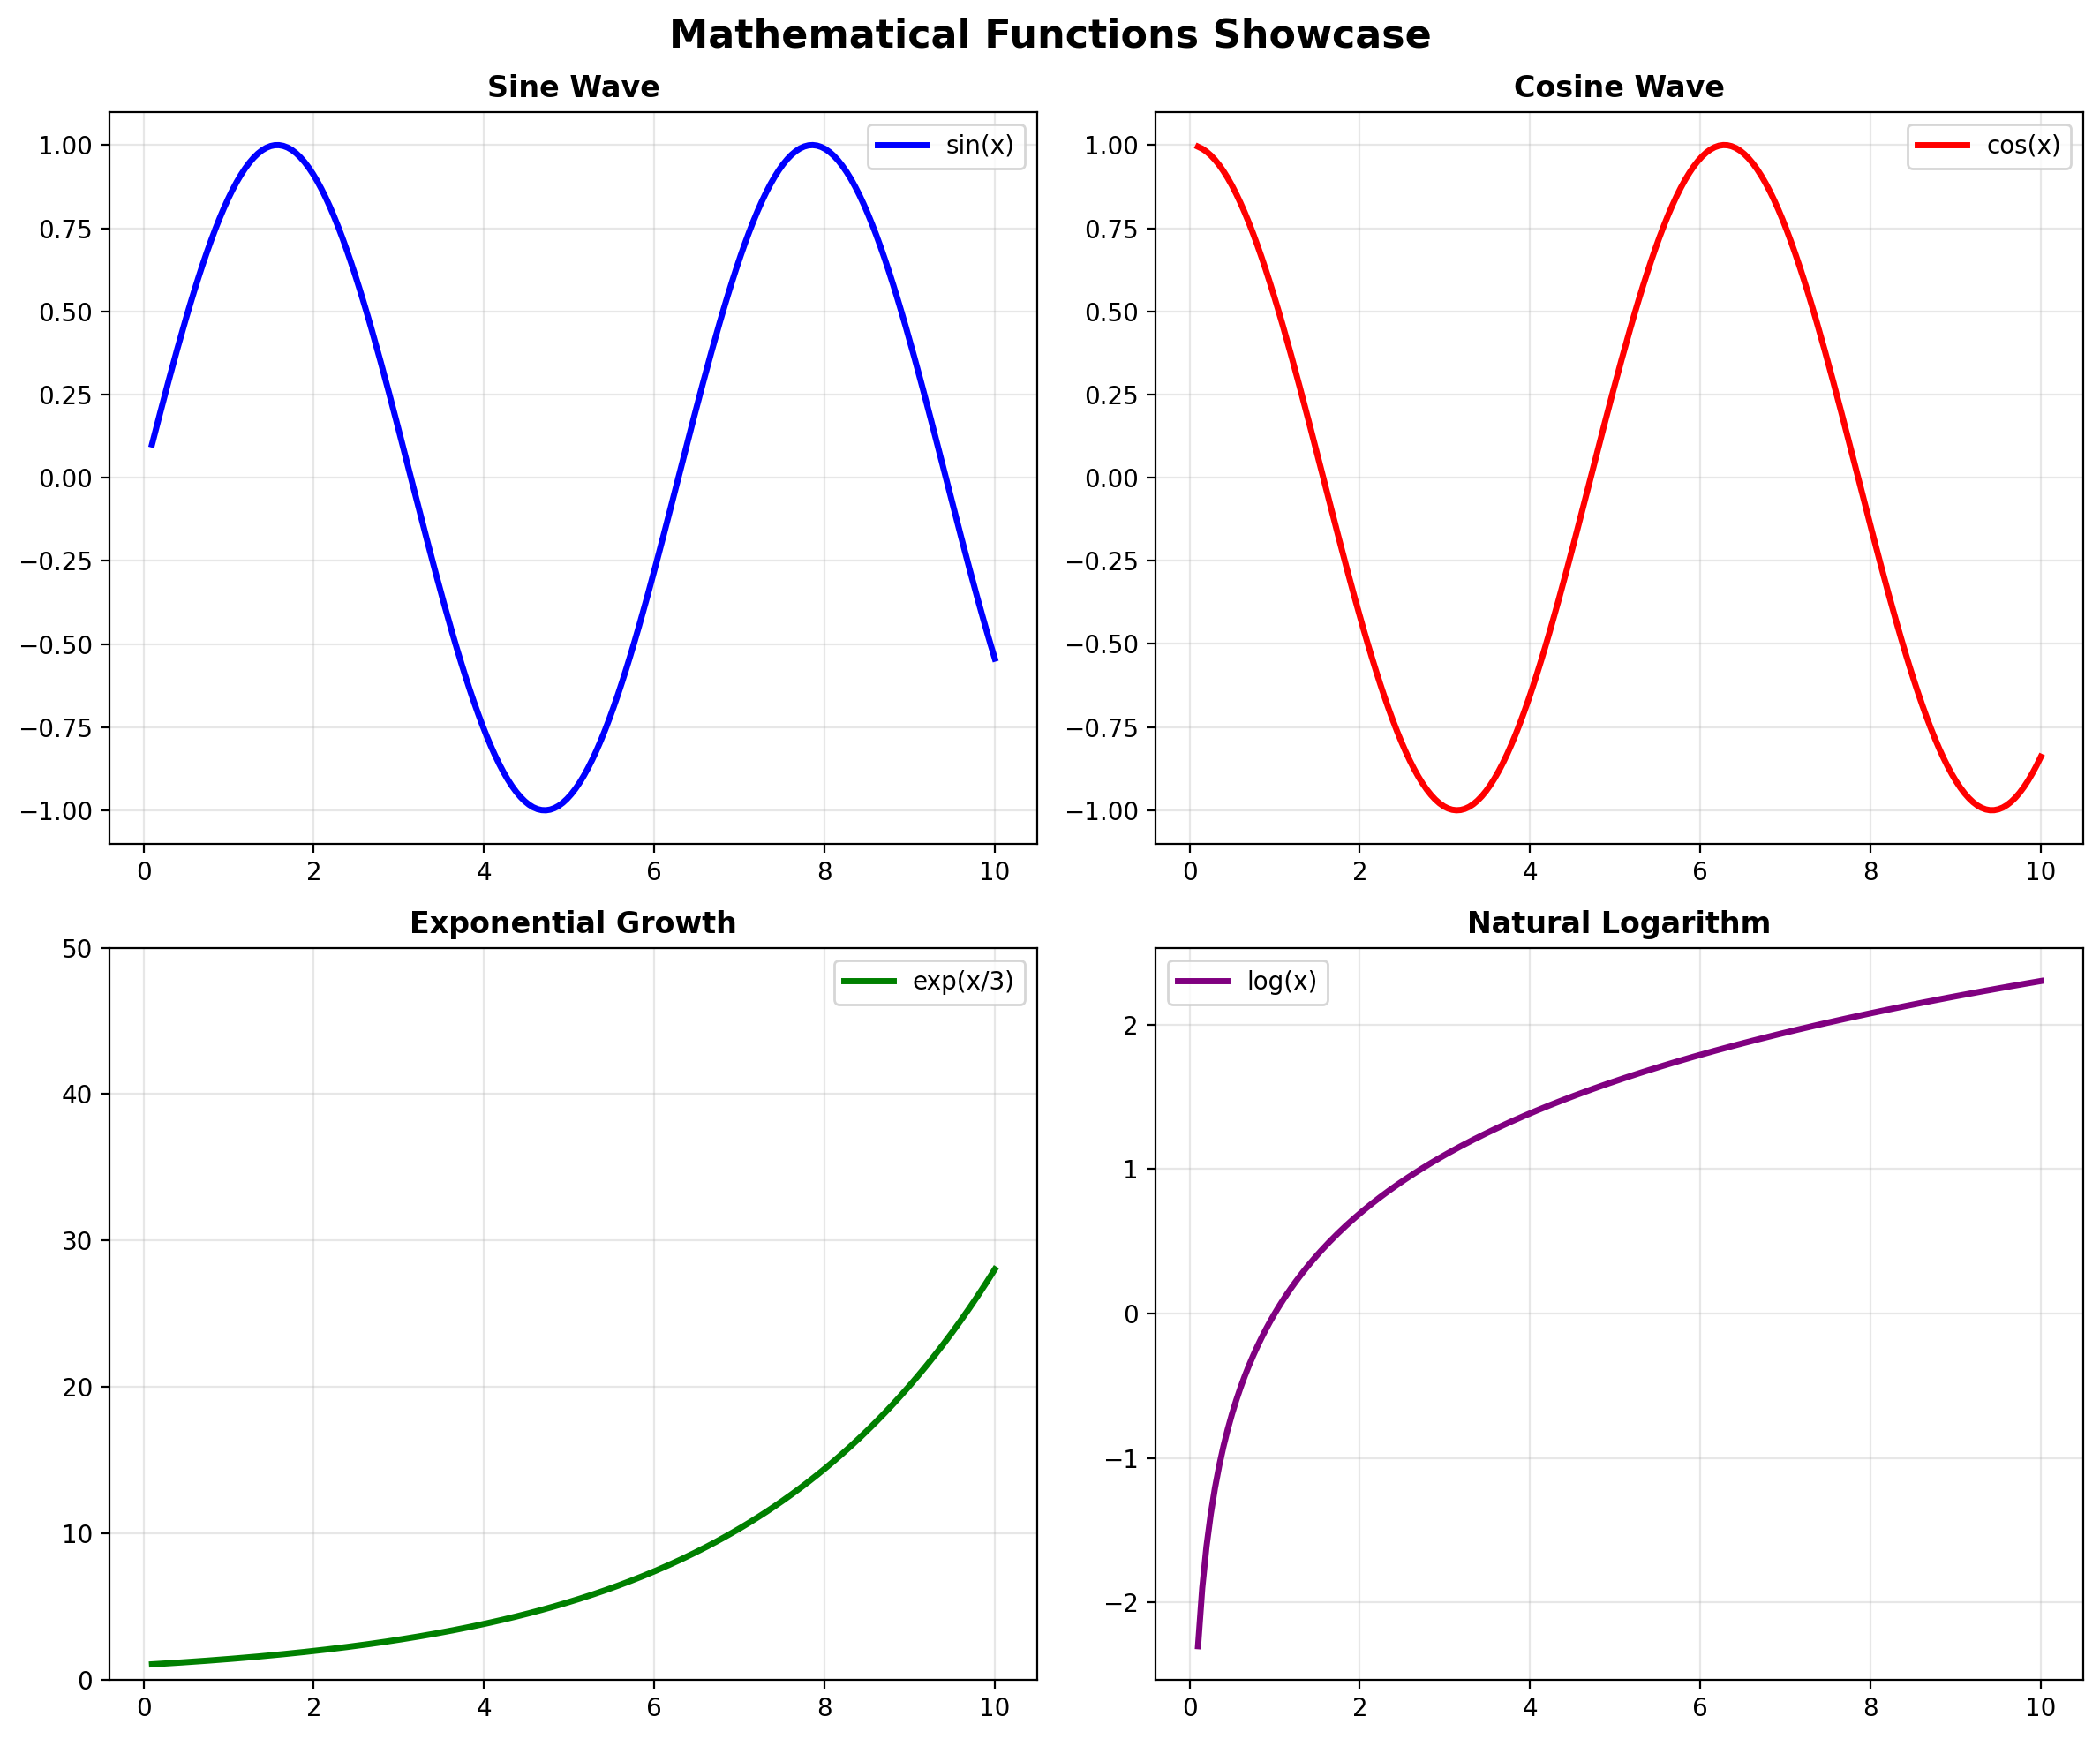

In [25]:
import matplotlib.pyplot as plt
# Configure backend
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}

# Create styled subplots
x = np.linspace(0.1, 10, 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Mathematical Functions Showcase', fontsize=16, fontweight='bold')

axes[0, 0].plot(x, np.sin(x), 'b-', linewidth=2.5, label='sin(x)')
axes[0, 0].set_title('Sine Wave', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, np.cos(x), 'r-', linewidth=2.5, label='cos(x)')
axes[0, 1].set_title('Cosine Wave', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(x, np.exp(x/3), 'g-', linewidth=2.5, label='exp(x/3)')
axes[1, 0].set_title('Exponential Growth', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 50)

axes[1, 1].plot(x, np.log(x), 'purple', linewidth=2.5, label='log(x)')
axes[1, 1].set_title('Natural Logarithm', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Solution 7: Debugging Practice


In [26]:
# Enable debugger
%pdb on

def safe_divide_list(numbers, divisor):
    """Divide each number by divisor - has bug with zero."""
    results = []
    for i, num in enumerate(numbers):
        # Bug: no check for divisor == 0
        result = num / divisor
        results.append(result)
    return results

# Uncomment to trigger debugger:
# safe_divide_list([10, 20, 30], 0)

print("Debugger enabled. Uncomment the function call to test.")
print("In pdb prompt: type 'divisor' to see the value, 'q' to quit")


Automatic pdb calling has been turned ON
Debugger enabled. Uncomment the function call to test.
In pdb prompt: type 'divisor' to see the value, 'q' to quit


### Solution 8: Shell Integration


### Solution 9: Precision Control


In [28]:
# Generate random matrix
matrix = np.random.randn(5, 5)

print("Default precision:")
print(matrix)

print("\n" + "="*50)
%precision 3
print("Precision set to 3 decimal places:")
print(matrix)

print("\n" + "="*50)
%precision %r
print("Reset to default (repr):")
print(matrix)


Default precision:
[[-0.33009019  0.956295    2.32467331 -0.01700607  0.50502109]
 [ 0.08451848 -0.71358467 -1.82076028 -0.70577348 -1.39195838]
 [ 1.70410208 -0.11510969 -0.34591933  0.88915382 -1.1217511 ]
 [-0.76686404  0.06807227  1.02876899  0.50168505  0.24832514]
 [ 0.07811774  0.40023586  0.20165291 -1.02997227  0.04607922]]

Precision set to 3 decimal places:
[[-0.33   0.956  2.325 -0.017  0.505]
 [ 0.085 -0.714 -1.821 -0.706 -1.392]
 [ 1.704 -0.115 -0.346  0.889 -1.122]
 [-0.767  0.068  1.029  0.502  0.248]
 [ 0.078  0.4    0.202 -1.03   0.046]]

Reset to default (repr):
[[-0.33   0.956  2.325 -0.017  0.505]
 [ 0.085 -0.714 -1.821 -0.706 -1.392]
 [ 1.704 -0.115 -0.346  0.889 -1.122]
 [-0.767  0.068  1.029  0.502  0.248]
 [ 0.078  0.4    0.202 -1.03   0.046]]


### Solution 10: Complete Workflow


In [29]:
# Step 1: Set seed
np.random.seed(42)
print("Step 1: Random seed set to 42")

# Step 2: Generate data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
print(f"Step 2: Generated data - X.shape: {X.shape}, y.shape: {y.shape}")


Step 1: Random seed set to 42
Step 2: Generated data - X.shape: (1000, 10), y.shape: (1000,)


In [30]:
%%time
# Step 3: Time preprocessing
print("Step 3: Timing preprocessing...")

def preprocess_pipeline(X):
    """Standard preprocessing: scale and add polynomial features."""
    from sklearn.preprocessing import StandardScaler, PolynomialFeatures
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_scaled)
    
    return X_poly

X_processed = preprocess_pipeline(X)
print(f"Processed shape: {X_processed.shape}")


Step 3: Timing preprocessing...
Processed shape: (1000, 65)
CPU times: total: 93.8 ms
Wall time: 50.9 ms


In [31]:
%%writefile preprocessor.py
"""
Data Preprocessor Module
Generated in Day 27 Exercise
"""
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

class DataPreprocessor:
    def __init__(self, poly_degree=2):
        self.scaler = StandardScaler()
        self.poly = PolynomialFeatures(degree=poly_degree, include_bias=False)
    
    def fit_transform(self, X):
        X_scaled = self.scaler.fit_transform(X)
        return self.poly.fit_transform(X_scaled)

if __name__ == "__main__":
    import numpy as np
    X = np.random.randn(100, 5)
    prep = DataPreprocessor()
    print(f"Original: {X.shape}, Processed: {prep.fit_transform(X).shape}")


Writing preprocessor.py


In [33]:
# Step 6: List all variables
print("Step 6: Final workspace state:")
%whos

print("\n" + "="*50)
print("✅ Complete workflow executed successfully!")


Step 6: Final workspace state:
Variable                Type             Data/Info
--------------------------------------------------
X                       ndarray          1000x10: 10000 elems, type `float64`, 80000 bytes
X_processed             ndarray          1000x65: 65000 elems, type `float64`, 520000 bytes (507.8125 kb)
accuracy                function         <function accuracy at 0x000002A6F071C900>
all_vars                list             n=15
arr                     ndarray          100000: 100000 elems, type `int64`, 800000 bytes (781.25 kb)
arrays_only             list             n=2
axes                    ndarray          2x2: 4 elems, type `object`, 32 bytes
config_dict             dict             n=2
counter                 int              42
data_list               list             n=5
data_size               int              100000
description             str              Machine Learning Experiment
f                       TextIOWrapper    <_io.TextIOWrapper name